# Dataset 01 — Material Comparison Analysis

## Objective

Quantitatively analyse the validated batch-experiment results for four ion-exchange materials evaluated for treatment of low-level radioactive liquid waste (LLW).

## Analysis questions

1. Which ion-exchange material produces the highest distribution coefficient (Kd) for each radionuclide?
2. How does radionuclide-specific performance differ between materials?
3. What fraction of activity remains after treatment?
4. Does the material with the highest batch adsorption performance necessarily represent the best engineering choice?

## Data source

The notebook uses the version-controlled Dataset 01 CSV:

`data/material_comparison/dataset_01_material_comparison.csv`

The dataset contains source experimental values together with the derived `remaining_activity_pct` field documented in the accompanying data dictionary.

In [1]:
# Dataset 01 — Load and inspect data

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Repository-relative path
DATA_PATH = Path("../../data/material_comparison/dataset_01_material_comparison.csv")

# Load dataset
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset shape: (16, 10)
Rows: 16
Columns: 10


,material,analyte,initial_activity_bq_ml,final_activity_bq_ml,remaining_activity_pct,kd_ml_g,equilibration_time_h,sample_volume_ml,material_mass_g,source_table
0,4A,Gross beta-gamma,146.0,26.10,17.876712,91.88,6,20,1,"M.Tech thesis, Table 3.1 and Table 3.2"
1,13X-CFC,Gross beta-gamma,146.0,9.95,6.815068,273.47,6,20,1,"M.Tech thesis, Table 3.1 and Table 3.2"
2,HMO-PU,Gross beta-gamma,146.0,31.50,21.575342,72.70,6,20,1,"M.Tech thesis, Table 3.1 and Table 3.2"
3,CFC-PU,Gross beta-gamma,146.0,7.78,5.328767,355.32,6,20,1,"M.Tech thesis, Table 3.1 and Table 3.2"
4,4A,90Sr,15.0,1.30,8.666667,210.77,6,20,1,"M.Tech thesis, Table 3.1 and Table 3.2"


In [2]:
# Basic structural validation

print("Columns:")
for column in df.columns:
    print(f"  - {column}")

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Columns:
  - material
  - analyte
  - initial_activity_bq_ml
  - final_activity_bq_ml
  - remaining_activity_pct
  - kd_ml_g
  - equilibration_time_h
  - sample_volume_ml
  - material_mass_g
  - source_table

Missing values:
material                  0
analyte                   0
initial_activity_bq_ml    0
final_activity_bq_ml      0
remaining_activity_pct    0
kd_ml_g                   0
equilibration_time_h      0
sample_volume_ml          0
material_mass_g           0
source_table              0
dtype: int64

Duplicate rows: 0


In [3]:
# Experimental groups

print("Materials:")
print(df["material"].unique())

print("\nAnalytes:")
print(df["analyte"].unique())

print("\nObservations per material:")
print(df["material"].value_counts())

print("\nObservations per analyte:")
print(df["analyte"].value_counts())

Materials:
['4A' '13X-CFC' 'HMO-PU' 'CFC-PU']

Analytes:
['Gross beta-gamma' '90Sr' '137Cs' '99Tc']

Observations per material:
material
4A         4
13X-CFC    4
HMO-PU     4
CFC-PU     4
Name: count, dtype: int64

Observations per analyte:
analyte
Gross beta-gamma    4
90Sr                4
137Cs               4
99Tc                4
Name: count, dtype: int64


In [4]:
# Dataset 01 — Data quality gate

numeric_columns = [
    "initial_activity_bq_ml",
    "final_activity_bq_ml",
    "remaining_activity_pct",
    "kd_ml_g",
    "equilibration_time_h",
    "sample_volume_ml",
    "material_mass_g",
]

print("Missing values:")
print(df.isna().sum())

print("\nNegative numeric values:")
for column in numeric_columns:
    count = (df[column] < 0).sum()
    print(f"{column}: {count}")

print("\nRemaining activity range:")
print(
    f"{df['remaining_activity_pct'].min():.3f}% "
    f"to {df['remaining_activity_pct'].max():.3f}%"
)

print("\nKd range:")
print(
    f"{df['kd_ml_g'].min():.2f} "
    f"to {df['kd_ml_g'].max():.2f} mL/g"
)

Missing values:
material                  0
analyte                   0
initial_activity_bq_ml    0
final_activity_bq_ml      0
remaining_activity_pct    0
kd_ml_g                   0
equilibration_time_h      0
sample_volume_ml          0
material_mass_g           0
source_table              0
dtype: int64

Negative numeric values:
initial_activity_bq_ml: 0
final_activity_bq_ml: 0
remaining_activity_pct: 0
kd_ml_g: 0
equilibration_time_h: 0
sample_volume_ml: 0
material_mass_g: 0

Remaining activity range:
0.588% to 47.414%

Kd range:
22.18 to 3380.00 mL/g


In [5]:
# Independent validation of the derived remaining-activity field

df["remaining_activity_pct_check"] = (
    df["final_activity_bq_ml"]
    / df["initial_activity_bq_ml"]
    * 100
)

df["remaining_activity_difference"] = (
    df["remaining_activity_pct"]
    - df["remaining_activity_pct_check"]
)

print(
    df[
        [
            "material",
            "analyte",
            "remaining_activity_pct",
            "remaining_activity_pct_check",
            "remaining_activity_difference",
        ]
    ].to_string(index=False)
)

print(
    "\nMaximum absolute difference:",
    df["remaining_activity_difference"].abs().max()
)

material          analyte  remaining_activity_pct  remaining_activity_pct_check  remaining_activity_difference
      4A Gross beta-gamma               17.876712                     17.876712                  -3.287671e-07
 13X-CFC Gross beta-gamma                6.815068                      6.815068                   6.849315e-09
  HMO-PU Gross beta-gamma               21.575342                     21.575342                  -4.657534e-07
  CFC-PU Gross beta-gamma                5.328767                      5.328767                  -2.328767e-08
      4A             90Sr                8.666667                      8.666667                   3.333333e-08
 13X-CFC             90Sr                5.666667                      5.666667                   3.333333e-08
  HMO-PU             90Sr                5.533333                      5.533333                  -3.333333e-08
  CFC-PU             90Sr                1.000000                      1.000000                   0.000000e+00
 

## 1. Distribution Coefficient (Kd) Comparison

The distribution coefficient (`Kd`) is compared across the four ion-exchange materials for each analyte.

For each radionuclide, the material with the highest `Kd` is identified and ranked against the alternatives.

In [6]:
# Kd ranking by analyte

kd_ranking = (
    df[["analyte", "material", "kd_ml_g"]]
    .sort_values(["analyte", "kd_ml_g"], ascending=[True, False])
    .reset_index(drop=True)
)

kd_ranking

,analyte,material,kd_ml_g
0,137Cs,CFC-PU,3380.00
1,137Cs,13X-CFC,660.00
2,137Cs,4A,174.29
3,137Cs,HMO-PU,41.82
4,90Sr,CFC-PU,1980.00
5,90Sr,HMO-PU,341.45
6,90Sr,13X-CFC,332.94
7,90Sr,4A,210.77
8,99Tc,13X-CFC,91.36
9,99Tc,CFC-PU,78.31


In [7]:
# Highest-Kd material for each analyte

best_kd = (
    df.loc[
        df.groupby("analyte")["kd_ml_g"].idxmax(),
        ["analyte", "material", "kd_ml_g"]
    ]
    .sort_values("analyte")
    .reset_index(drop=True)
)

best_kd

,analyte,material,kd_ml_g
0,137Cs,CFC-PU,3380.00
1,90Sr,CFC-PU,1980.00
2,99Tc,13X-CFC,91.36
3,Gross beta-gamma,CFC-PU,355.32


In [8]:
# Kd advantage of the best material over the second-best material

kd_spread = (
    df[["analyte", "material", "kd_ml_g"]]
    .sort_values(["analyte", "kd_ml_g"], ascending=[True, False])
    .groupby("analyte")
    .head(2)
    .groupby("analyte")["kd_ml_g"]
    .agg(["max", "min"])
)

kd_spread["absolute_difference_ml_g"] = (
    kd_spread["max"] - kd_spread["min"]
)

kd_spread["best_to_second_ratio"] = (
    kd_spread["max"] / kd_spread["min"]
)

kd_spread

,max,min,absolute_difference_ml_g,best_to_second_ratio
analyte,,,,
137Cs,3380.00,660.00,2720.00,5.121212
90Sr,1980.00,341.45,1638.55,5.798799
99Tc,91.36,78.31,13.05,1.166645
Gross beta-gamma,355.32,273.47,81.85,1.299302


## 2. Radionuclide-Specific Material Performance

The Kd results show that material performance is strongly radionuclide-dependent. This section compares the four materials across analytes to determine whether a single material consistently performs best or whether material effectiveness depends on the radionuclide.

In [9]:
# Material × analyte Kd matrix

kd_matrix = df.pivot(
    index="material",
    columns="analyte",
    values="kd_ml_g"
)

kd_matrix

analyte,137Cs,90Sr,99Tc,Gross beta-gamma
material,,,,
13X-CFC,660.00,332.94,91.36,273.47
4A,174.29,210.77,22.18,91.88
CFC-PU,3380.00,1980.00,78.31,355.32
HMO-PU,41.82,341.45,68.78,72.70


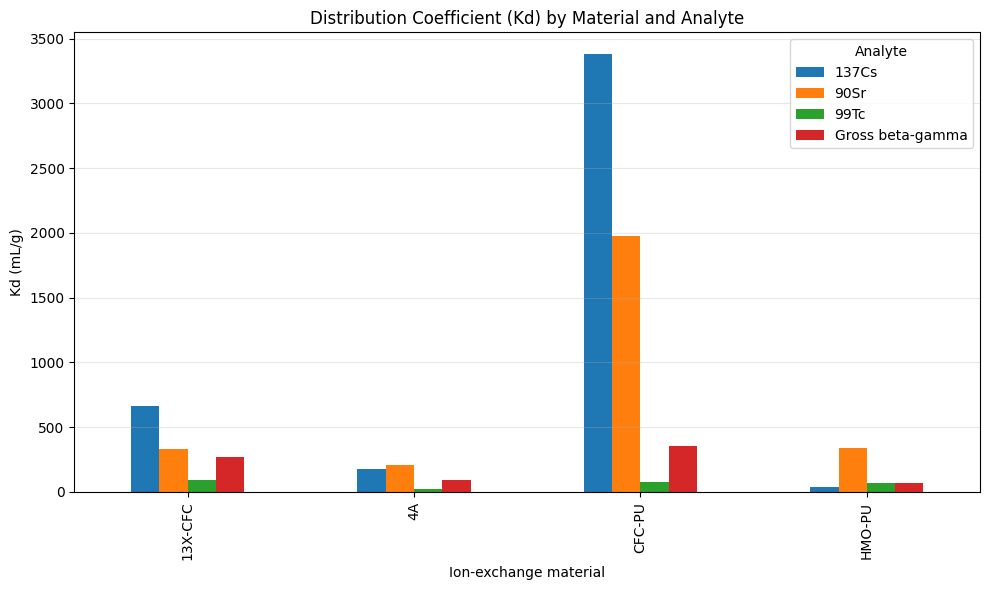

In [10]:
# Kd comparison across materials and analytes

plot_data = df.pivot(
    index="material",
    columns="analyte",
    values="kd_ml_g"
)

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Distribution Coefficient (Kd) by Material and Analyte")
ax.set_xlabel("Ion-exchange material")
ax.set_ylabel("Kd (mL/g)")
ax.legend(title="Analyte")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

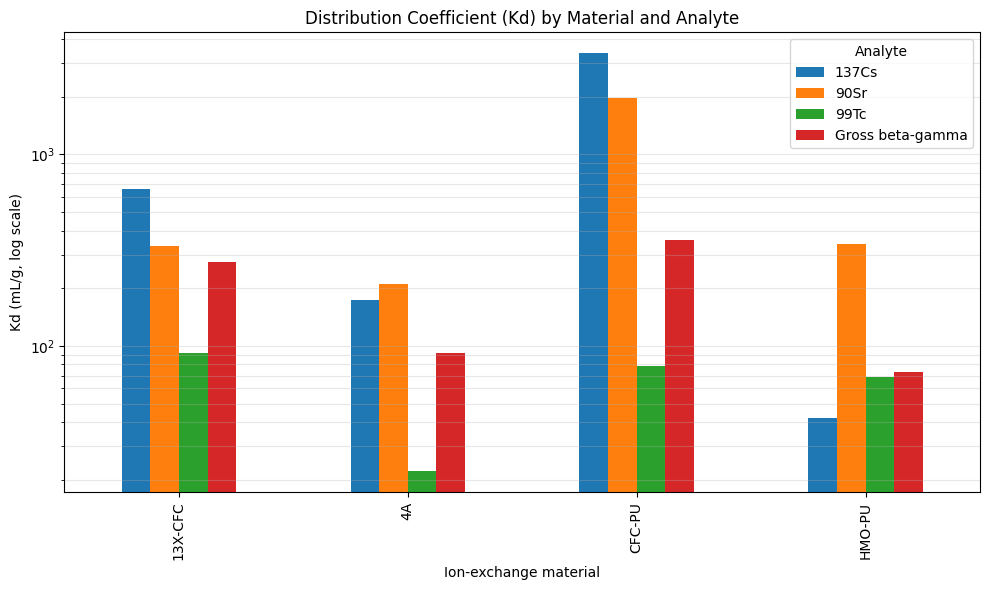

In [11]:
# Log-scale Kd comparison

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6),
    logy=True
)

ax.set_title("Distribution Coefficient (Kd) by Material and Analyte")
ax.set_xlabel("Ion-exchange material")
ax.set_ylabel("Kd (mL/g, log scale)")
ax.legend(title="Analyte")
ax.grid(axis="y", alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## 3. Residual Activity After Treatment

The residual activity percentage is calculated as the fraction of initial activity remaining in the liquid phase after treatment. Lower values indicate greater apparent removal under the batch-experiment conditions.

In [12]:
# Residual activity (%) by material and analyte

remaining_matrix = df.pivot(
    index="material",
    columns="analyte",
    values="remaining_activity_pct"
)

remaining_matrix

analyte,137Cs,90Sr,99Tc,Gross beta-gamma
material,,,,
13X-CFC,2.941177,5.666667,17.959770,6.815068
4A,10.294118,8.666667,47.413793,17.876712
CFC-PU,0.588235,1.000000,20.351437,5.328767
HMO-PU,32.352941,5.533333,22.528736,21.575342


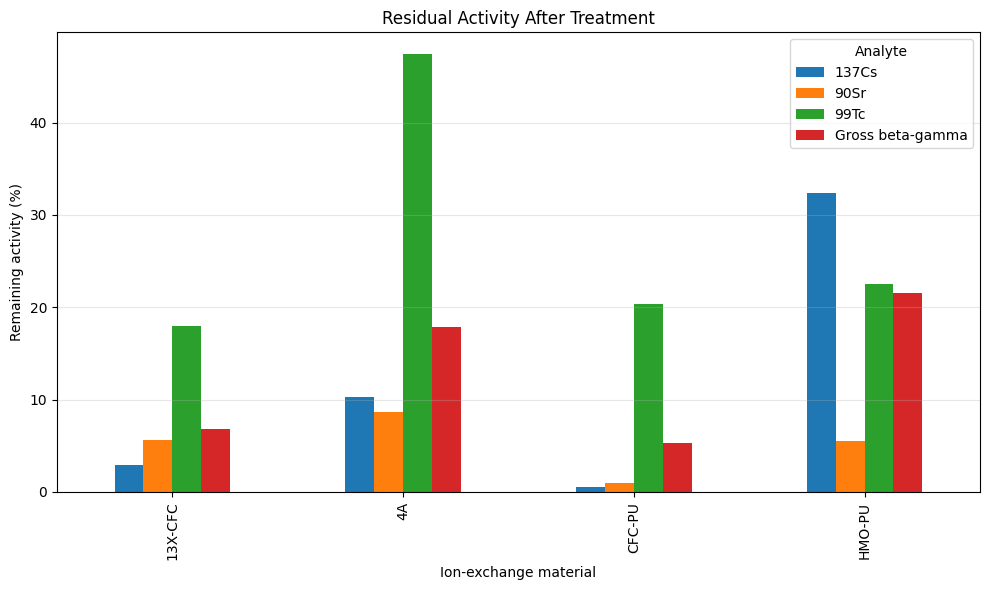

In [13]:
# Plot residual activity

ax = remaining_matrix.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Residual Activity After Treatment")
ax.set_xlabel("Ion-exchange material")
ax.set_ylabel("Remaining activity (%)")
ax.legend(title="Analyte")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Engineering Interpretation

The material with the highest distribution coefficient (Kd) does not necessarily represent the best engineering choice.

Batch Kd provides evidence of adsorption performance under the tested experimental conditions, but material selection for an engineered treatment system must also consider radionuclide selectivity, residual activity, equilibrium time, material loading, regeneration or disposal requirements, hydraulic performance, secondary waste generation, chemical stability, and scalability.

For Dataset 01, CFC-PU provides the strongest measured performance for 137Cs and 90Sr, while 13X-CFC provides the strongest performance for 99Tc. This indicates that a single material may not provide optimal treatment across all radionuclides.

The Dataset 01 results therefore support material-specific and radionuclide-specific evaluation rather than selecting a material solely on the basis of the maximum Kd value.

In [14]:
# Final performance summary

summary = (
    df.loc[
        df.groupby("analyte")["remaining_activity_pct"].idxmin(),
        [
            "analyte",
            "material",
            "kd_ml_g",
            "remaining_activity_pct"
        ]
    ]
    .copy()
)

summary["removal_efficiency_pct"] = (
    100 - summary["remaining_activity_pct"]
)

summary = summary.sort_values("analyte").reset_index(drop=True)

summary

,analyte,material,kd_ml_g,remaining_activity_pct,removal_efficiency_pct
0,137Cs,CFC-PU,3380.00,0.588235,99.411765
1,90Sr,CFC-PU,1980.00,1.000000,99.000000
2,99Tc,13X-CFC,91.36,17.959770,82.040230
3,Gross beta-gamma,CFC-PU,355.32,5.328767,94.671233


## Results and Discussion

### Distribution coefficient

The distribution coefficient (Kd) varied substantially with both ion-exchange material and analyte. CFC-PU exhibited the highest Kd for 137Cs (3380 mL/g), 90Sr (1980 mL/g), and gross beta-gamma (355.32 mL/g). For 99Tc, however, 13X-CFC produced the highest Kd (91.36 mL/g).

The magnitude of the differences was particularly pronounced for 137Cs and 90Sr, indicating strong material-dependent selectivity. The results demonstrate that material performance cannot be represented adequately by a single overall Kd value.

### Residual activity and removal

The residual-activity results were consistent with the Kd rankings. CFC-PU reduced the measured activity of 137Cs and 90Sr to 0.588% and 1.000% of their respective initial activities, corresponding to removal efficiencies of 99.41% and 99.00%.

For 99Tc, 13X-CFC produced the lowest residual activity at 17.96%, corresponding to 82.04% removal. For gross beta-gamma, CFC-PU produced the lowest residual activity at 5.33%, corresponding to 94.67% removal.

### Engineering interpretation

The material exhibiting the highest Kd is not necessarily the universally preferred engineering material. Dataset 01 demonstrates that performance is radionuclide-specific: CFC-PU provides the strongest measured performance for 137Cs and 90Sr, whereas 13X-CFC provides the strongest performance for 99Tc.

Consequently, material selection for an engineered radioactive-liquid-waste treatment system should consider the radionuclide composition of the waste stream rather than relying solely on the maximum Kd measured for an individual analyte. Additional engineering factors, including equilibrium time, material loading, hydraulic behaviour, chemical stability, regeneration or disposal requirements, secondary waste generation, and scale-up performance, would also need to be evaluated before process selection.

## Dataset 01 Conclusions

Dataset 01 demonstrates substantial differences in ion-exchange performance among the four evaluated materials. CFC-PU produced the highest Kd and lowest residual activity for 137Cs and 90Sr, while 13X-CFC performed best for 99Tc. CFC-PU also produced the lowest residual gross beta-gamma activity.

The results therefore support a radionuclide-specific approach to material selection. The batch experiments provide a quantitative screening basis, but they should not by themselves be interpreted as sufficient evidence for selection of a full-scale treatment medium.

## Limitations of Dataset 01

Dataset 01 contains one reported observation for each material–analyte combination. Consequently, the present analysis supports comparative point estimates of Kd, residual activity, and calculated removal efficiency, but does not support estimation of experimental variance, confidence intervals, or statistical significance between materials.

The results should therefore be interpreted as quantitative batch-experiment comparisons rather than replicated statistical comparisons. Replicated experiments under controlled conditions would be required to quantify measurement uncertainty and establish statistical significance.

In [15]:
# Compact Dataset 01 results table

final_results = (
    df[
        [
            "analyte",
            "material",
            "kd_ml_g",
            "remaining_activity_pct"
        ]
    ]
    .copy()
)

final_results["removal_efficiency_pct"] = (
    100 - final_results["remaining_activity_pct"]
)

final_results = final_results.sort_values(
    ["analyte", "kd_ml_g"],
    ascending=[True, False]
).reset_index(drop=True)

final_results

,analyte,material,kd_ml_g,remaining_activity_pct,removal_efficiency_pct
0,137Cs,CFC-PU,3380.00,0.588235,99.411765
1,137Cs,13X-CFC,660.00,2.941177,97.058824
2,137Cs,4A,174.29,10.294118,89.705882
3,137Cs,HMO-PU,41.82,32.352941,67.647059
4,90Sr,CFC-PU,1980.00,1.000000,99.000000
5,90Sr,HMO-PU,341.45,5.533333,94.466667
6,90Sr,13X-CFC,332.94,5.666667,94.333333
7,90Sr,4A,210.77,8.666667,91.333333
8,99Tc,13X-CFC,91.36,17.959770,82.040230
9,99Tc,CFC-PU,78.31,20.351437,79.648563


In [16]:
# Final calculation quality-control checks

df["kd_calculated_ml_g"] = (
    (df["initial_activity_bq_ml"] - df["final_activity_bq_ml"])
    / df["final_activity_bq_ml"]
    * df["sample_volume_ml"]
    / df["material_mass_g"]
)

df["kd_difference"] = (
    df["kd_ml_g"] - df["kd_calculated_ml_g"]
)

print("Maximum absolute Kd difference:")
print(df["kd_difference"].abs().max())

print("\nRows with |difference| > 0.01 mL/g:")
print(
    df.loc[
        df["kd_difference"].abs() > 0.01,
        [
            "material",
            "analyte",
            "kd_ml_g",
            "kd_calculated_ml_g",
            "kd_difference"
        ]
    ]
)

Maximum absolute Kd difference:
0.036840150798482796

Rows with |difference| > 0.01 mL/g:
   material analyte  kd_ml_g  kd_calculated_ml_g  kd_difference
15   CFC-PU    99Tc    78.31            78.27316        0.03684


In [ ]:
# Remove temporary QC columns
df = df.drop(
    columns=["kd_calculated_ml_g", "kd_difference"]
)

print("Final dataset columns:")
print(df.columns.tolist())

Final dataset columns:
['material', 'analyte', 'initial_activity_bq_ml', 'final_activity_bq_ml', 'remaining_activity_pct', 'kd_ml_g', 'equilibration_time_h', 'sample_volume_ml', 'material_mass_g', 'source_table', 'remaining_activity_pct_check', 'remaining_activity_difference']


## 1. Environment and imports

The analysis uses standard Python data-analysis libraries. No statistical inference or machine-learning model is introduced at this stage.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.6g}')

## 2. Load Dataset 01

The relative path below assumes that the notebook is executed from the repository root. If the notebook is opened in another working directory, adjust the path without modifying the underlying dataset.

In [ ]:
DATA_PATH = '../../data/material_comparison/dataset_01_material_comparison.csv'

df = pd.read_csv(DATA_PATH)
df.head()

## 3. Basic dataset inspection

In [ ]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

df.info()

In [ ]:
df.describe(include='all').T

In [ ]:
print('Materials:', df['material'].unique().tolist())
print('Analytes:', df['analyte'].unique().tolist())
print('Equilibration times:', df['equilibration_time_h'].unique().tolist())

## 4. Data-quality checks

Dataset 01 is expected to contain 16 observations: four materials × four analytes.

In [ ]:
expected_rows = 4 * 4
assert len(df) == expected_rows, f'Expected {expected_rows} rows, found {len(df)}'

expected_materials = {'4A', '13X-CFC', 'HMO-PU', 'CFC-PU'}
expected_analytes = {'Gross beta-gamma', '90Sr', '137Cs', '99Tc'}

assert set(df['material']) == expected_materials
assert set(df['analyte']) == expected_analytes
assert df[['initial_activity_bq_ml', 'final_activity_bq_ml', 'remaining_activity_pct', 'kd_ml_g']].notna().all().all()

duplicates = df.duplicated(subset=['material', 'analyte']).sum()
assert duplicates == 0, f'Found {duplicates} duplicate material/analyte combinations'

print('All Dataset 01 structural checks passed.')

In [ ]:
# Verify the derived remaining-activity field.
calculated_remaining = (
    df['final_activity_bq_ml'] / df['initial_activity_bq_ml'] * 100
)

max_difference = (calculated_remaining - df['remaining_activity_pct']).abs().max()
print(f'Maximum difference in remaining_activity_pct: {max_difference:.10g}')

assert np.allclose(
    calculated_remaining,
    df['remaining_activity_pct'],
    rtol=1e-6,
    atol=1e-6
)

print('Derived-field validation passed.')

## 5. Validation status

At this stage the notebook performs only structural and data-quality validation. Analytical rankings, visualizations and engineering interpretation will be added in subsequent sections after the baseline dataset passes these checks.